## Data Acquisition & Wrangling

Implement dual-row header parsing for date construction.

Use label-based filtering via dictionary mapping for target indicators.

Clean string-formatted currency values into floats (comma removal).

Align disparate rows into a single Time-Series DataFrame.

In [11]:
import pandas as pd
import numpy as np

def extract_monetary_data(file_path):
    # Use 'low_memory=False' because monetary data often has mixed types
    df = pd.read_csv(file_path, low_memory=False)

    # 1. Extract Dates (Years and Months)
    years_row = df.columns.tolist()
    current_year = None
    years = []
    for col in years_row:
        if col.isdigit(): current_year = col
        years.append(current_year)
    
    # Months are in the second row (index 1)
    months = df.iloc[1].tolist()
    
    # Create the date index (aligning with data columns)
    date_strings = [f"{y}-{m}" for y, m in zip(years[2:], months[2:]) if pd.notna(y) and pd.notna(m)]
    dates = pd.to_datetime(date_strings, format='%Y-%b', errors='coerce')

    # 2. Target Dictionary (Fixed commas and exact labels)
    target_indicators = {
        "Net Foreign assets": "NFA",
        "Net Domestic Assets": "NDA",
        "Reserve Money": "Reserve_Money",
        "Currency in circulation": "Currency_Circ",
        "Banks Reserves at CBK": "Total_Reserves",
        "Public Non Financial Corp": "SOE_Credit",
        "Private sector credit ": "Private_Credit", # Note the space
        "Central Government (Net)": "Gov_Credit",
        "Money and Quasi-money (M2)": "M2",
        "M2 plus Residents' Foreign Curr. Deposits (M3)": "M3",
        "Required reserves": "Req_Reserves",
        "Excess reserves": "Excess_Reserves"
    }

    cleaned_series = []
    labels_col = df.columns[1] # The column containing text labels

    # 3. Process each indicator (Logic moved INSIDE the function)
    for label, short_name in target_indicators.items():
        # regex=False treats parentheses like '(M2)' as plain text
        mask = df[labels_col].astype(str).str.strip().str.contains(label.strip(), case=False, na=False, regex=False)
        
        if mask.any():
            # Get the very last match (the aggregate survey at the bottom)
            row_data = df[mask].iloc[-1, 2:].values 
            
            # Clean numeric values (remove commas and handle blanks)
            clean_vals = []
            for x in row_data:
                try:
                    s = str(x).replace(',', '').strip()
                    clean_vals.append(float(s) if s != '' else np.nan)
                except ValueError:
                    clean_vals.append(np.nan)
            
            # Ensure the data matches our date length
            cleaned_series.append(pd.Series(clean_vals[:len(dates)], name=short_name))
        else:
            print(f"⚠️ Warning: Could not find label '{label}' in CSV.")

    if not cleaned_series:
        print("❌ No data was extracted. Check if the labels match your CSV column.")
        return pd.DataFrame()

    # Re-build the DataFrame and attach the dates
    monetary_df = pd.concat(cleaned_series, axis=1)
    monetary_df.index = dates
    return monetary_df

# --- EXECUTION ---
# Use r'' for Windows paths to avoid 'unicodeescape' errors
csv_path = r'D:\Asaph_Ray\DATA SCIENCE\DATA ANALYSIS\CBK MACROECONOMIC ANALYSIS\cbk-macroeconomic-analysis\data\cleaned\monetary.csv'

# Run the extraction (Naming the variable 'df_monetary' to keep the function safe)
df_monetary = extract_monetary_data(csv_path)

if not df_monetary.empty:
    # Perform the "8 Point" analysis calculations
    if 'Excess_Reserves' in df_monetary.columns and 'Req_Reserves' in df_monetary.columns:
        df_monetary['Liquidity_Buffer_Ratio'] = (df_monetary['Excess_Reserves'] / 
                                                (df_monetary['Req_Reserves'] + df_monetary['Excess_Reserves'])) * 100
    
    if 'M3' in df_monetary.columns and 'Reserve_Money' in df_monetary.columns:
        df_monetary['Money_Multiplier'] = df_monetary['M3'] / df_monetary['Reserve_Money']

    df_monetary.to_csv('monetary_cleaned.csv')
    print("✅ Successfully cleaned and analyzed")
    print(df_monetary[['M2', 'M3', 'Gov_Credit']].tail()) # Display a small sample

✅ Successfully cleaned and analyzed
                   M2        M3  Gov_Credit
2025-07-01  11.843577  6.727829   20.776003
2025-08-01   9.775533  7.214904   21.540094
NaT         11.135488  7.576694   32.337368
2025-10-01  11.288173  8.489005   22.424007
2025-11-01  10.677925  8.376810   12.473543


## 1. Year-over-Year (YoY) Growth
The YoY growth rate removes "seasonal noise" (like typical December spending spikes) by comparing a month to the same month in the previous year.
$$\text{YoY Growth} = \left( \frac{\text{Value}_{t}}{\text{Value}_{t-12}} - 1 \right) \times 100$$

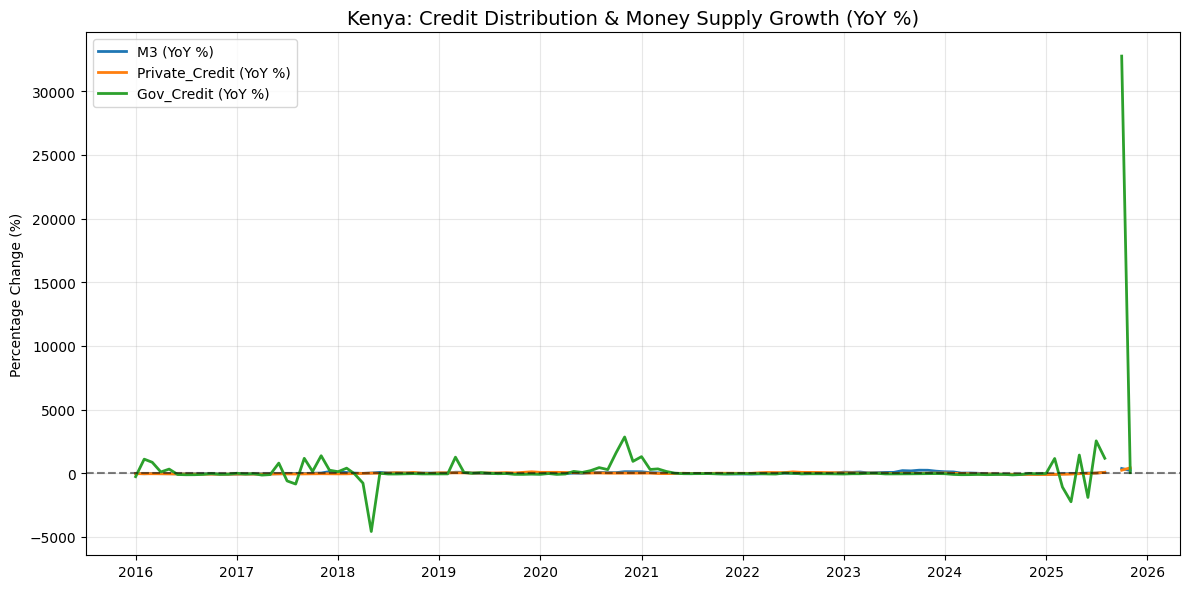

In [ ]:
import matplotlib.pyplot as plt

# 1. Run the extraction (ensure you use a new variable name 'df_monetary')
df_monetary = extract_monetary_data(file_path)

# 2. Calculating YoY Growth safely
# We drop all-NaN rows first to ensure the 12-month window is accurate
df_yoy = df_monetary.dropna(how='all').pct_change(periods=12) * 100

# 3. Visualization: The Big Three (M3, Private Credit, Govt Credit)
plt.figure(figsize=(12, 6))

# Define columns to show for a cleaner chart
cols_to_plot = ['M3', 'Private_Credit', 'Gov_Credit']

for col in cols_to_plot:
    if col in df_yoy.columns:
        plt.plot(df_yoy.index, df_yoy[col], label=f'{col} (YoY %)', linewidth=2)

plt.axhline(0, color='black', linestyle='--', alpha=0.5) 
plt.title('Kenya: Credit Distribution & Money Supply Growth (YoY %)', fontsize=14)
plt.ylabel('Percentage Change (%)')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Credit Composition (Private vs. Government)
This analysis identifies who is receiving the most credit in this economy. A high share of government credit relative to private credit can signal "Crowding Out," where government borrowing makes it harder or more expensive for businesses to get loans.

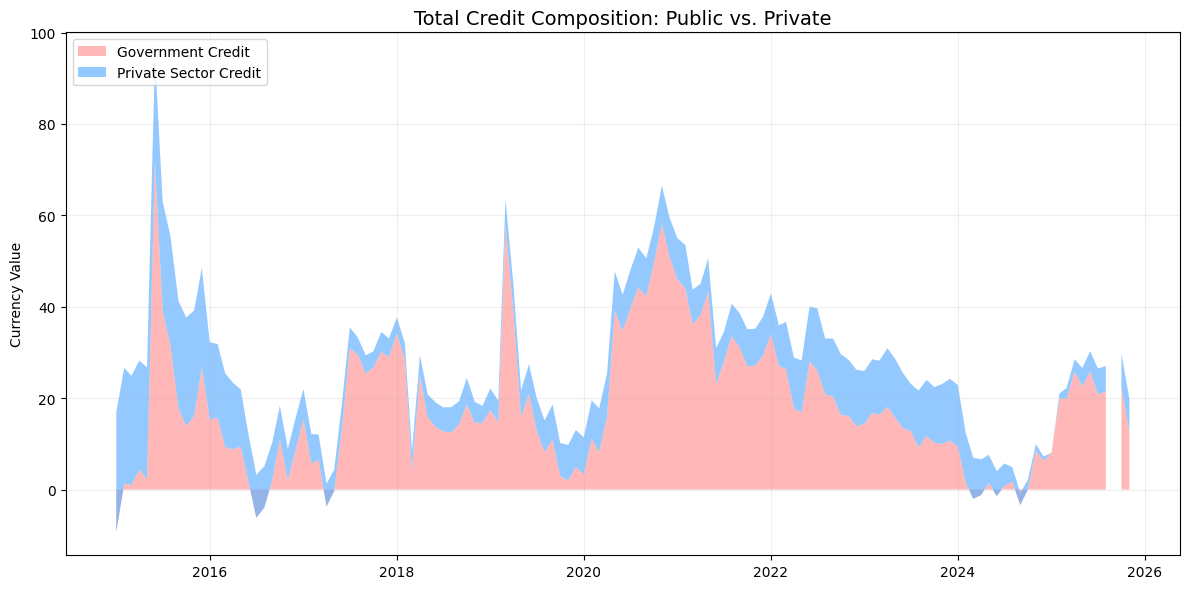

In [18]:
# 1. Calculating the Private Sector's share of total credit
total_credit = df_monetary['Private_Credit'] + df_monetary['Gov_Credit']
df_monetary['Private_Credit_Share'] = (df_monetary['Private_Credit'] / total_credit) * 100

# 2. Visualizing with a Stacked Area Chart
plt.figure(figsize=(12, 6))
plt.stackplot(df_monetary.index, 
              df_monetary['Gov_Credit'], 
              df_monetary['Private_Credit'], 
              labels=['Government Credit', 'Private Sector Credit'],
              alpha=0.7, colors=['#ff9999','#66b3ff'])

plt.title('Total Credit Composition: Public vs. Private', fontsize=14)
plt.ylabel('Currency Value')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Money Aggregate Comparison ($M2$ vs $M3$)
Comparing $M2$ and $M3$ shows the "liquidity depth." If the gap between $M3$ and $M2$ is widening, it usually means residents are holding more foreign currency deposits or long-term savings.

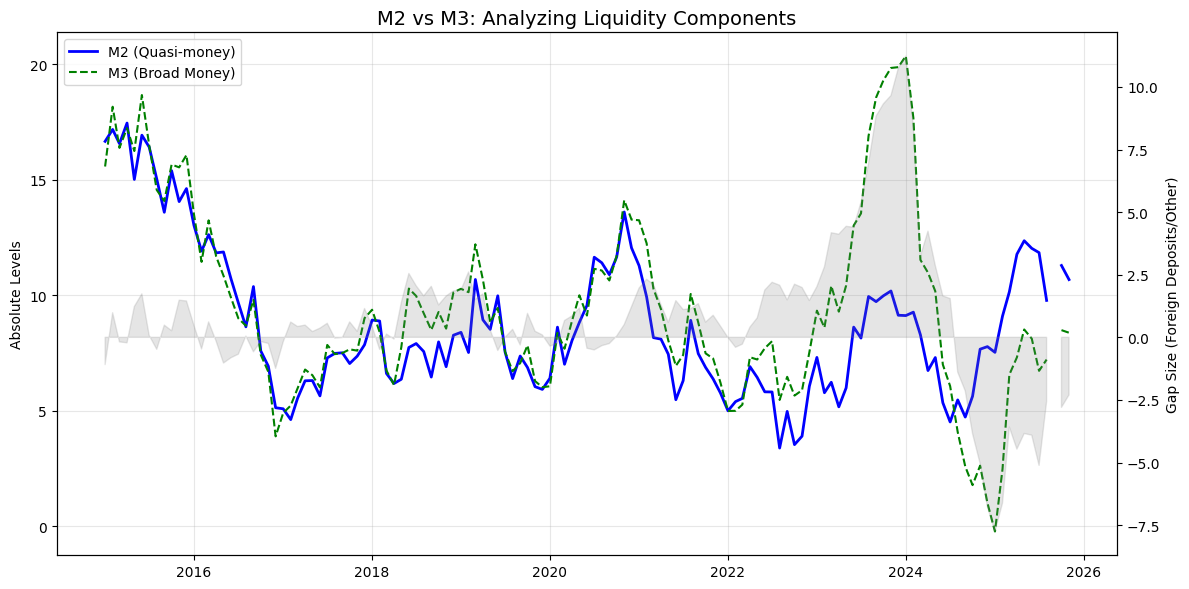

In [19]:
# 1. Let's calculate the spread/gap
df_monetary['M3_M2_Gap'] = df_monetary['M3'] - df_monetary['M2']

# 2. Visualize Levels and the Gap
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_monetary.index, df_monetary['M2'], label='M2 (Quasi-money)', color='blue', linewidth=2)
ax1.plot(df_monetary.index, df_monetary['M3'], label='M3 (Broad Money)', color='green', linestyle='--')
ax1.set_ylabel('Absolute Levels')
ax1.legend(loc='upper left')

# Creating a second y-axis for the gap
ax2 = ax1.twinx()
ax2.fill_between(df_monetary.index, df_monetary['M3_M2_Gap'], color='gray', alpha=0.2, label='M3-M2 Gap')
ax2.set_ylabel('Gap Size (Foreign Deposits/Other)')

plt.title('M2 vs M3: Analyzing Liquidity Components', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.Seasonal Decomposition
This is the "X-Ray" of the data. It breaks  M2 or Private_Credit into three distinct parts:

Trend: The long-term "true" direction (ignoring the monthly ups and downs).

Seasonal: The repeating yearly cycle (e.g., do people always withdraw cash in December?).

Residual: The "shocks" or unexpected events (like a sudden policy change).

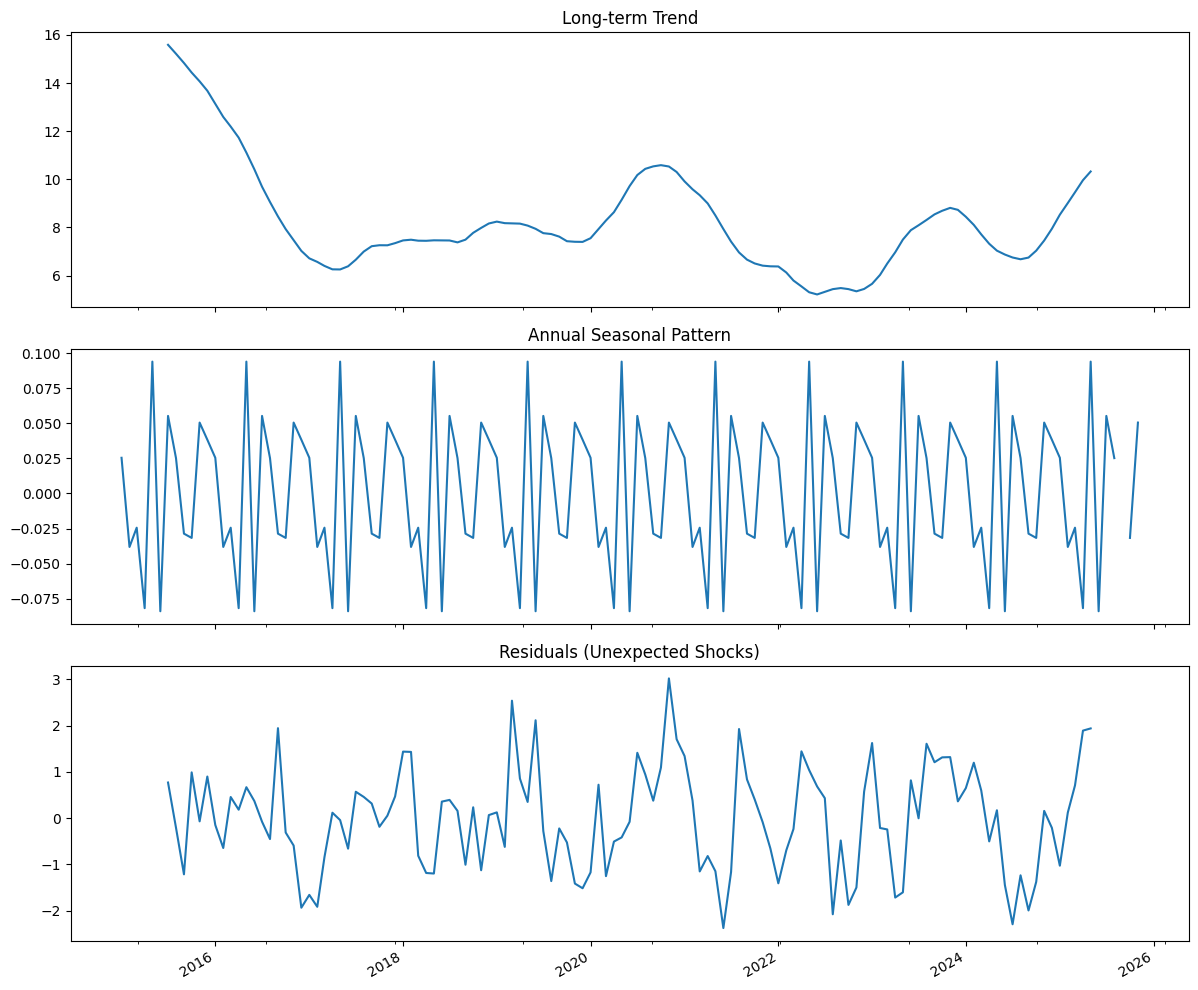

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We'll use M2 as the primary example
# Ensure 'monetary' has a frequency set (usually monthly 'MS')
result = seasonal_decompose(df_monetary['M2'].dropna(), model='additive', period=12)

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
result.trend.plot(ax=ax1, title='Long-term Trend')
result.seasonal.plot(ax=ax2, title='Annual Seasonal Pattern')
result.resid.plot(ax=ax3, title='Residuals (Unexpected Shocks)')
plt.tight_layout()
plt.show()

## 5.Correlation Heatmap
This tells how "synchronized" these variables are.

A 1.0 (dark red) means they move perfectly together.

A 0 means they have nothing to do with each other.

A negative number means when one goes up, the other goes down (uncommon in monetary aggregates but possible in credit).

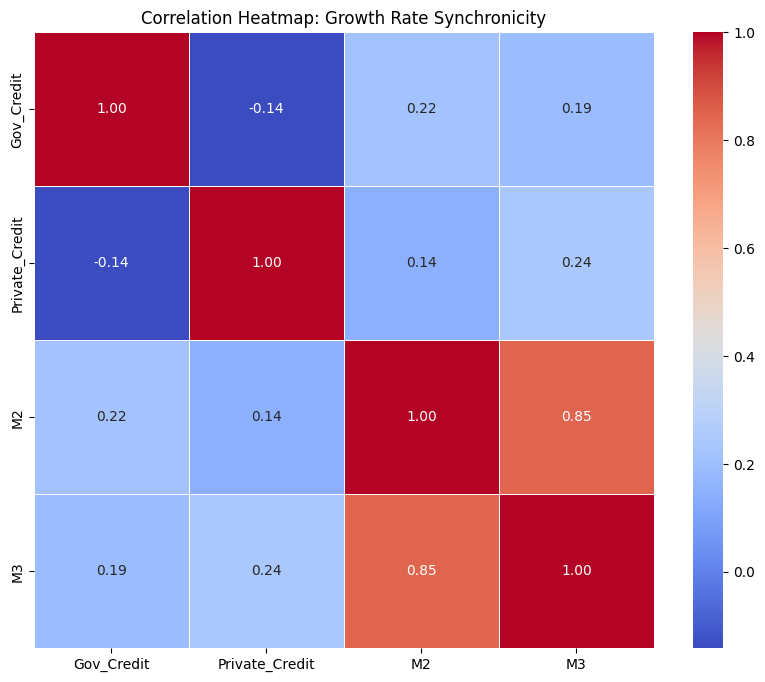

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
# We calculate the correlation of the growth rates, not the absolute levels, 
# because absolute levels almost always trend up together (which can be misleading).
correlation_matrix = monetary[['Gov_Credit', 'Private_Credit', 'M2', 'M3']].pct_change().corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Growth Rate Synchronicity')
plt.show()

## 6. Rolling Volatility (The "Stress" Test)
A calculation of a Rolling Standard Deviation. This tells how "jumpy" the credit growth is. Huge spikes in this chart usually marks a period of economic crisis or massive policy shifts.

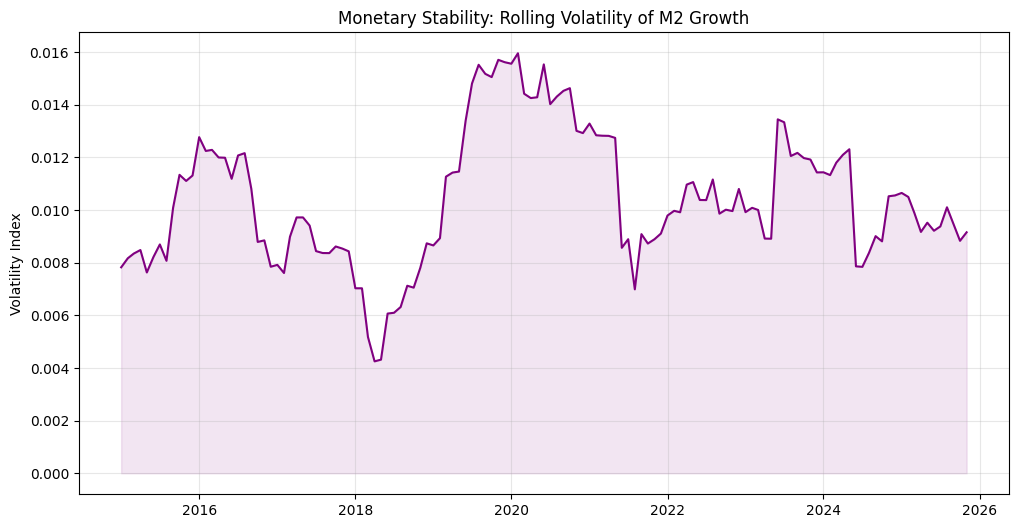

In [44]:
# Calculate the volatility (Standard Deviation) of M2 growth over a 12-month window
monetary['M2_Volatility'] = monetary['M2'].pct_change().rolling(window=12).std()

plt.figure(figsize=(12, 6))
plt.plot(monetary.index, monetary['M2_Volatility'], color='purple', label='M2 Volatility (12m Window)')
plt.fill_between(monetary.index, monetary['M2_Volatility'], color='purple', alpha=0.1)
plt.title('Monetary Stability: Rolling Volatility of M2 Growth')
plt.ylabel('Volatility Index')
plt.grid(True, alpha=0.3)
plt.show()

## 7. The Money Multiplier Analysis
A critical metric for a Central Bank. It tells us how effectively the CBK's "Reserve Money" is being turned into "Broad Money" by the commercial banks. If this ratio drops, it means banks are holding onto cash rather than lending it out.
$$\text{Money Multiplier} = \frac{M3}{\text{Reserve Money}}$$

## 8. The Backing Ratio (Currency Stability)
This measures how much of Kenya's money supply is backed by actual foreign reserves (dollars, gold, etc.) versus domestic debt.High Ratio: Stronger support for the KES exchange rate.Low Ratio: Suggests the money supply is largely driven by domestic borrowing.
$$\text{Backing Ratio} = \frac{\text{NFA}}{\text{M3}}$$

I'm trying to look at the specific Monetary Survey structure of Kenya. Just moved from just looking at "how much money exists" to "how that money is backed" and 'how effectively the banking system is creating it.'

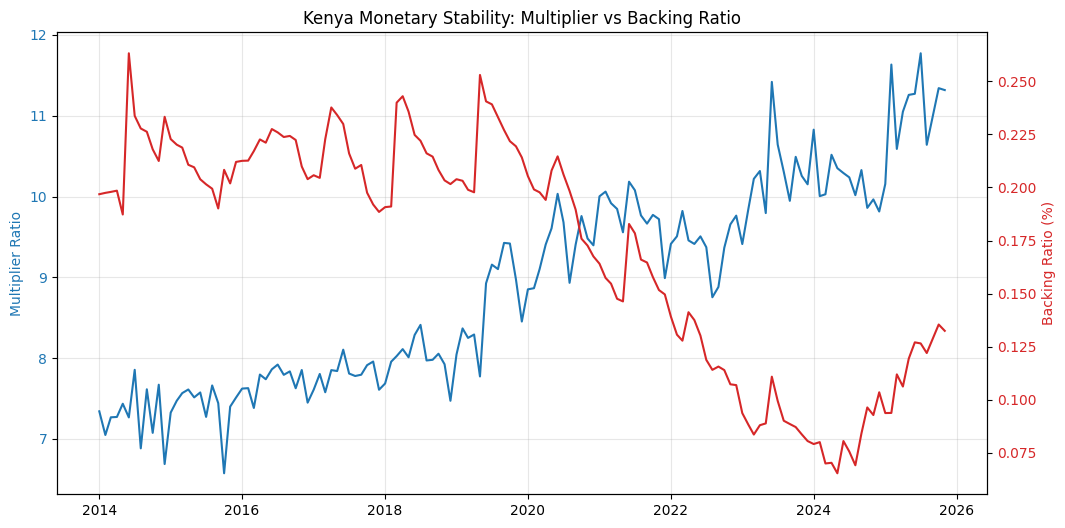

In [45]:
# 1. Calculating Ratios
monetary['Money_Multiplier'] = monetary['M3'] / monetary['Reserve_Money']
monetary['Backing_Ratio'] = monetary['NFA'] / monetary['M3']

# 2. Visualize
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Multiplier
ax1.plot(monetary.index, monetary['Money_Multiplier'], color='tab:blue', label='Money Multiplier (M3/RM)')
ax1.set_ylabel('Multiplier Ratio', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plotting Backing Ratio on secondary axis
ax2 = ax1.twinx()
ax2.plot(monetary.index, monetary['Backing_Ratio'], color='tab:red', label='Backing Ratio (NFA/M3)')
ax2.set_ylabel('Backing Ratio (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Kenya Monetary Stability: Multiplier vs Backing Ratio')
ax1.grid(True, alpha=0.3)
plt.show()

## The "Lazy Money" Analysis (Excess Liquidity)
When banks hold significant excess reserves, it often means they are either being extremely cautious about lending or that the interest rates they earn elsewhere (like on Government Tontines or T-Bills) aren't attractive enough to move the cash.

In [48]:
# We calculate the Liquidity Buffer Ratio
monetary['Liquidity_Buffer_Ratio'] = (monetary['Excess_Reserves'] / 
                                     (monetary['Req_Reserves'] + monetary['Excess_Reserves'])) * 100

KeyError: 'Excess_Reserves'

In [ ]:
# Visualization: The Reserve Stack
plt.figure(figsize=(12, 6))
plt.stackplot(monetary.index, 
              monetary['Req_Reserves'], 
              monetary['Excess_Reserves'], 
              labels=['Required Reserves (The Floor)', 'Excess Reserves (Lazy Money)'],
              colors=['#2ca02c', '#d62728'], alpha=0.7)

plt.title('Kenyan Banking Liquidity: Required vs Excess Reserves', fontsize=14)
plt.ylabel('Amount (KES Millions)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# Visualization: The "Lazy Money" Index
plt.figure(figsize=(12, 4))
plt.plot(monetary.index, monetary['Liquidity_Buffer_Ratio'], color='orange', linewidth=2)
plt.axhline(monetary['Liquidity_Buffer_Ratio'].mean(), color='black', linestyle='--', alpha=0.5, label='Historical Avg')
plt.title('The "Lazy Money" Index: % of Reserves Not Being Lent', fontsize=14)
plt.ylabel('Percentage (%)')
plt.legend()
plt.show()

KeyError: 'Liquidity_Buffer_Ratio'

<Figure size 1200x400 with 0 Axes>